# FIR Filter Theory and Implementation

In [2]:
from matplotlib.pyplot import (
    figure,
    grid,
    legend,
    plot,
    title,
    show,
    xlabel,
    ylabel,
)
from numpy import arange, linspace, pi, sin
from scipy.fftpack import fft

## Generate a sample noisy signal

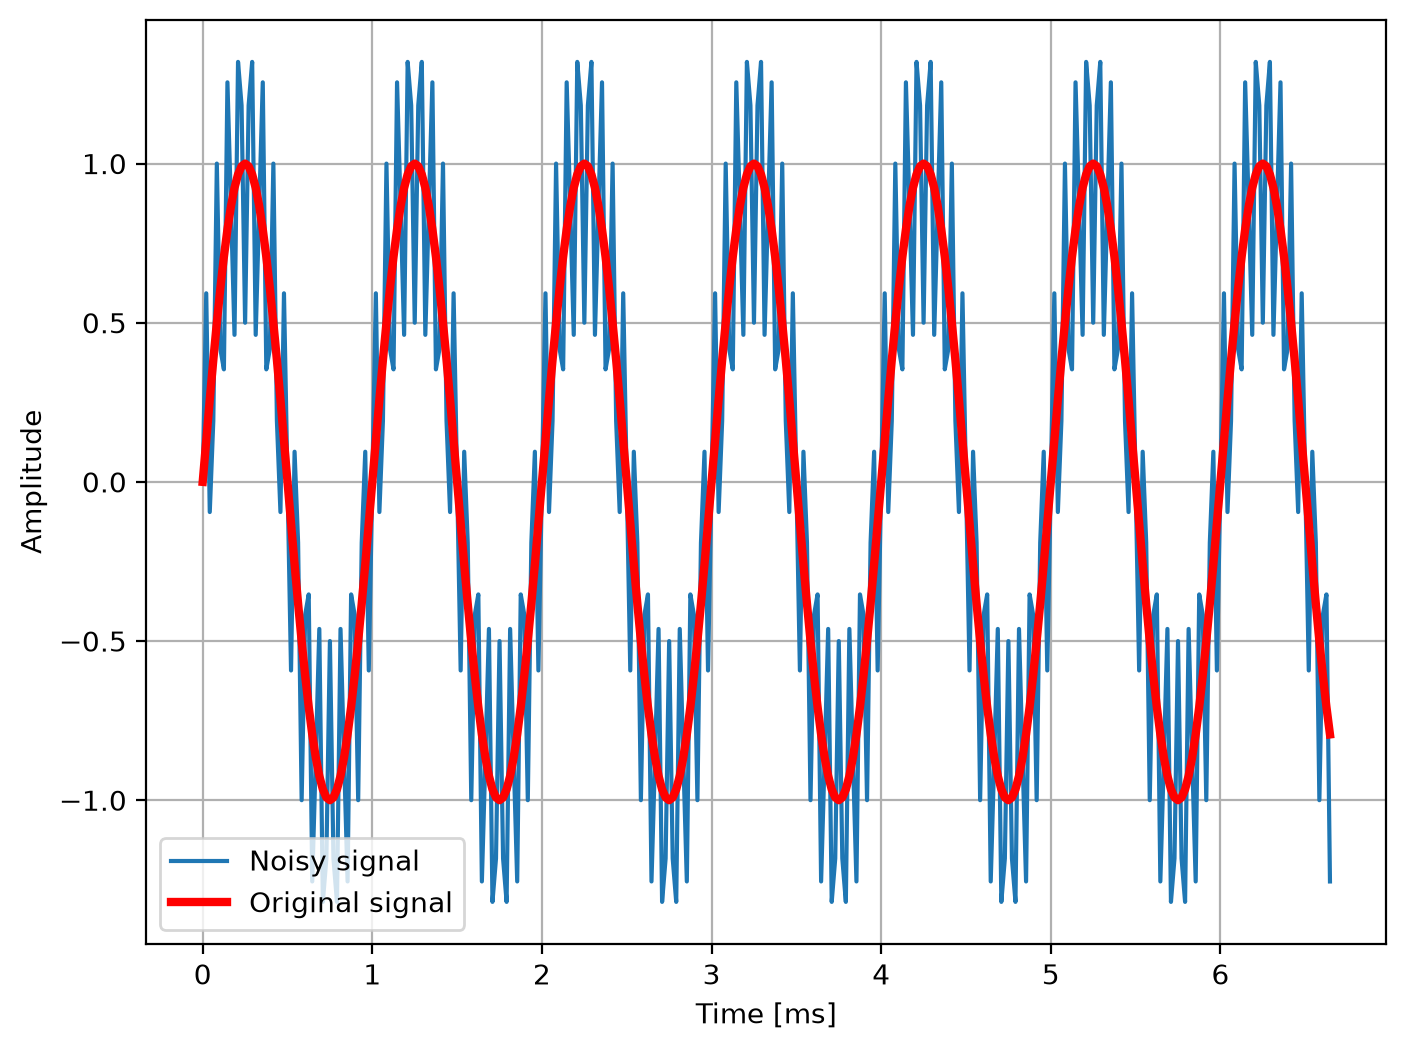

In [3]:
sampling_freq_hz = 48000
n_samples = 320

noise_freq_hz = 15e3
noise_amp = 0.5

signal_freq_hz = 1e3
signal_amp = 1

t = arange(n_samples) / sampling_freq_hz

noise = noise_amp * sin(2 * pi * noise_freq_hz * t)
signal = signal_amp * sin(2 * pi * signal_freq_hz * t)
noisy_signal = noise + signal

figure(1, figsize=(8, 6), dpi=200)
plot(t * 1e3, noisy_signal, label="Noisy signal")
plot(t * 1e3, signal, "r-", linewidth=3, label="Original signal")
xlabel("Time [ms]")
ylabel("Amplitude")
legend()
grid(True)
show()

## Plot the original signal and noisy signal's FFT

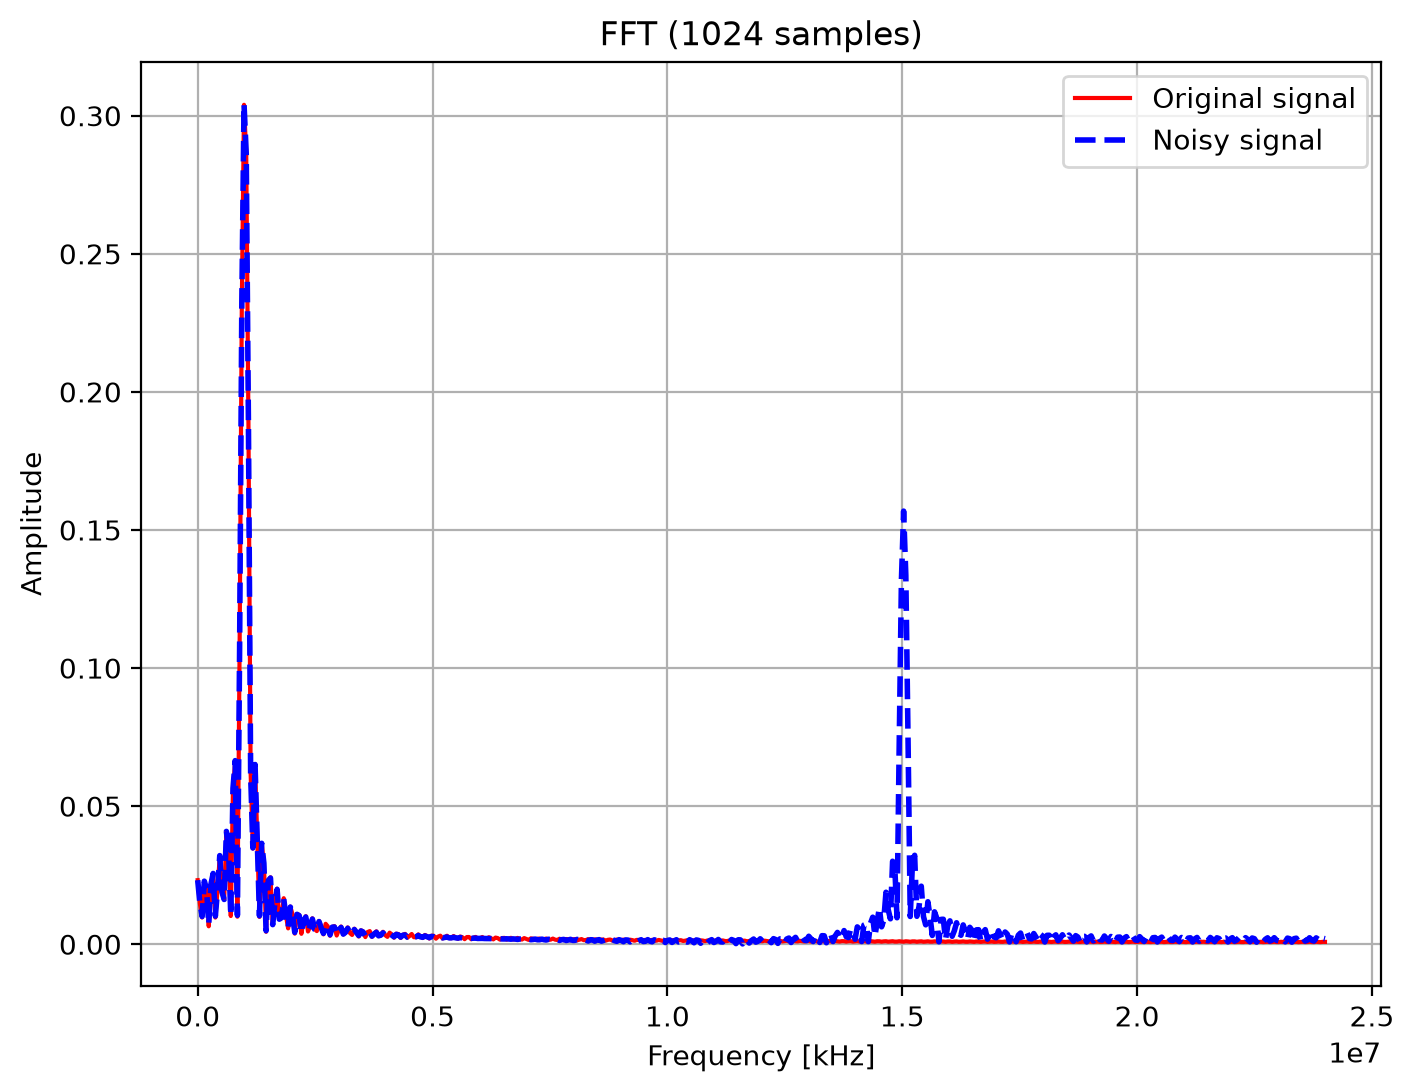

In [5]:
n_fft = 1024
fft_signal = fft(signal, n_fft)
fft_noisy_signal = fft(noisy_signal, n_fft)
x_fft = linspace(0.0, 1.0 / (2.0 * t[1]), n_fft // 2)

figure(2, figsize=(8, 6), dpi=200)
title(f"FFT ({n_fft} samples)")
plot(
    x_fft * 1e3,
    2.0 / n_fft * abs(fft_signal[0 : n_fft // 2]),
    "r",
    label="Original signal",
)
plot(
    x_fft * 1e3,
    2.0 / n_fft * abs(fft_noisy_signal[0 : n_fft // 2]),
    "b--",
    linewidth=2,
    label="Noisy signal",
)
xlabel("Frequency [kHz]")
ylabel("Amplitude")
legend()
grid(True)
show()